In [ ]:
from datasets import load_dataset
import numpy as np

# one representative per modality you need
targets = {
    "images":     "legacysurvey",
    "spectra":    "sdss",
    "lightcurve": "plasticc",
    "xray":       "chandra",
}

def peek(name):
    dset = load_dataset(f"MultimodalUniverse/{name}", split="train", streaming=True)
    ex = next(iter(dset.with_format("numpy")))
    print(f"\n=== {name} ===")
    for k, v in ex.items():
        if isinstance(v, np.ndarray):
            print(f"  {k:20s} array  shape={v.shape} dtype={v.dtype}")
        elif isinstance(v, dict):
            print(f"  {k:20s} dict   keys={list(v.keys())}")
        else:
            print(f"  {k:20s} {type(v).__name__:6s} {str(v)[:60]}")

for _, name in targets.items():
    peek(name)

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

# --- 1. IMAGE: a literal photo of a patch of sky ---
img_dset = load_dataset("MultimodalUniverse/legacysurvey", split="train", streaming=True)
img_ex = next(iter(img_dset.with_format("numpy")))

# --- 2. SPECTRUM: brightness split into a rainbow, plotted as a graph ---
spec_dset = load_dataset("MultimodalUniverse/sdss", split="train", streaming=True)
spec_ex = next(iter(spec_dset.with_format("numpy")))

# --- 3. LIGHT CURVE: brightness over time, plotted as a graph ---
lc_dset = load_dataset("MultimodalUniverse/plasticc", split="train", streaming=True)
lc_ex = next(iter(lc_dset.with_format("numpy")))

# --- Plot all three side by side ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Image: just show it
axes[0].imshow(img_ex['rgb'])
axes[0].set_title(f"Image\nobject_id: {img_ex['object_id']}")
axes[0].axis('off')

# Spectrum: brightness vs wavelength
spec = spec_ex['spectrum']
axes[1].plot(spec['lambda'], spec['flux'], linewidth=0.7)
axes[1].set_title(f"Spectrum (z={spec_ex['Z']:.3f})")
axes[1].set_xlabel("Wavelength")
axes[1].set_ylabel("Brightness")

# Light curve: brightness vs time, colored by filter/band
lc = lc_ex['lightcurve']
for b in np.unique(lc['band']):
    mask = lc['band'] == b
    axes[2].scatter(lc['time'][mask], lc['flux'][mask], s=12, label=str(b))
axes[2].set_title(f"Light curve\ntype: {lc_ex['obj_type']}")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Brightness")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
import lsdb
from lsdb.streams import CatalogStream

In [ ]:
gz10 = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_gz10")
sdss = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_sdss_sdss")

# So the line with compute essentially walks through every tile and does the full spatial join, handing us back a final pd/dask object (df)
# xmatch = gz10.crossmatch(sdss, n_neighbors=1).compute()
# This gets everything ready to stream as below
xmatch = gz10.crossmatch(sdss, n_neighbors=1)

In [ ]:
row = next(iter(CatalogStream(catalog=xmatch))).head(1).iloc[0]      

In [ ]:
open("g.png", "wb").write(row["rgb_image_mmu_gz10"]["bytes"]) 

In [ ]:
row

In [ ]:
import matplotlib.pyplot as plt
import io
from PIL import Image

# spectrum
s = row["spectrum_mmu_sdss_sdss"]
s = s[~s["mask"]]        # drop masked/bad pixels

lambd = s["lambda"]      # wavelength array
flux  = s["flux"]        # flux array
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# panel 1: the galaxy image, properly decoded (not just the raw pixelated write)
img_bytes = row["rgb_image_mmu_gz10"]["bytes"]
img = Image.open(io.BytesIO(img_bytes))
axes[0].imshow(img)
axes[0].set_title("GZ10 image")
axes[0].axis("off")

# panel 2: the spectrum
axes[1].plot(lambd, flux)
axes[1].set_xlabel("Wavelength (Å)")
axes[1].set_ylabel("Flux")
axes[1].set_title("SDSS spectrum")

plt.tight_layout()
plt.savefig("pair.png", dpi=150)
plt.show()

In [ ]:
# moving along the iterator!

stream_iter = iter(CatalogStream(catalog=xmatch))
rows = []
for _ in range(5):
    partition = next(stream_iter)
    rows.append(partition.head(1).iloc[0])

In [ ]:
# Contents of a spectra entry?
s

In [1]:
import lsdb
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

# pull exactly 1 row
jwst = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_jwst_ceers")
sample = jwst.head(1)

row = next(sample.iterrows())[1]

Computing Catalog: 100%|██████████| 1/1 [00:08<00:00,  9.00s/it]


In [2]:
image_field = row['image']

In [14]:
image_field

,band,flux,ivar,mask,psf_fwhm,scale
0,f090w,"[[0.061043046, 0.038694587, -0.016987061, -0.0...","[[621.5091, 718.3215, 752.857, 687.90314, 790....","[[True, True, True, True, True, True, True, Tr...",0.033,0.04
1,f115w,"[[-0.037501547, -0.055467833, -0.05618196, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[False, False, False, False, False, False, Fa...",0.040,0.04
2,f150w,"[[-0.03791174, -0.09013518, -0.06392129, -0.00...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[False, False, False, False, False, False, Fa...",0.050,0.04
3,f200w,"[[-0.010914382, -0.013461866, -0.059939504, -0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[False, False, False, False, False, False, Fa...",0.066,0.04
4,f277w,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[False, False, False, False, False, False, Fa...",0.092,0.04
5,f356w,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[False, False, False, False, False, False, Fa...",0.116,0.04
6,f444w,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[False, False, False, False, False, False, Fa...",0.145,0.04


In [4]:
one_flux = image_field["flux"].to_list()[0]   # the f090w row
print(type(one_flux))
print(type(one_flux[0]))
print(one_flux[0][:3] if hasattr(one_flux[0], "__getitem__") else one_flux[0])

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[ 0.06104305  0.03869459 -0.01698706]


object_id: 1757963689505784943
bands available: ['f090w', 'f115w', 'f150w', 'f200w', 'f277w', 'f356w', 'f444w']


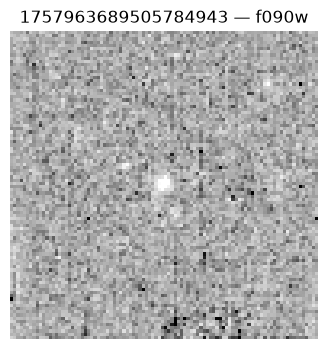

In [13]:
bands = [b.decode() if isinstance(b, (bytes, bytearray)) else str(b)
         for b in image_field["band"].tolist()]

flux = np.stack([np.stack(row).astype(np.float32) for row in image_field["flux"].to_list()])

print("object_id:", row["object_id"])
print("bands available:", bands)

band_name = "f090w"
i = bands.index(band_name)
img = flux[i]

norm = simple_norm(img, stretch="asinh", percent=99.75)

plt.figure(figsize=(4, 4))
plt.imshow(img, origin="lower", cmap="gray", norm=norm)
plt.title(f"{row['object_id']} — {band_name}")
plt.axis("off")
plt.show()

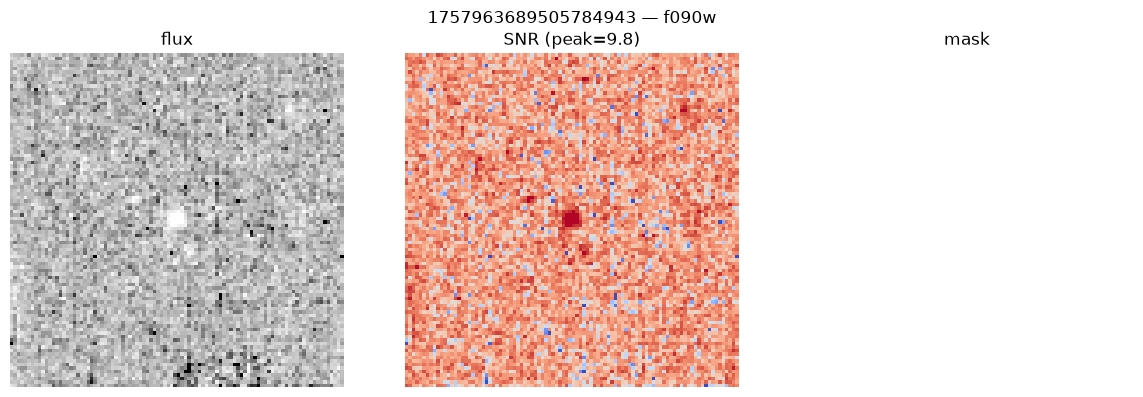

fraction of pixels masked: 1.0
peak SNR pixel is masked?: True


In [15]:
# extract ivar and mask the same way we fixed for flux
ivar = np.stack([np.stack(r).astype(np.float32) for r in image_field["ivar"].to_list()])[i]
mask = np.stack([np.stack(r).astype(bool)  for r in image_field["mask"].to_list()])[i]

# signal-to-noise per pixel
snr = img * np.sqrt(np.clip(ivar, 0, None))   # clip guards against any stray negative ivar

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# flux (what you already have)
norm = simple_norm(img, stretch="asinh", percent=99.5)
axes[0].imshow(img, origin="lower", cmap="gray", norm=norm)
axes[0].set_title("flux")
axes[0].axis("off")

# snr — symmetric stretch since snr can be negative, centered so 0 = mid-gray
snr_norm = simple_norm(snr, stretch="asinh", percent=99.5)
axes[1].imshow(snr, origin="lower", cmap="coolwarm", norm=snr_norm)
axes[1].set_title(f"SNR (peak={snr.max():.1f})")
axes[1].axis("off")

# mask — binary, no stretch needed
axes[2].imshow(mask, origin="lower", cmap="gray_r")  # gray_r: True(bad)=dark or light depending on convention
axes[2].set_title("mask")
axes[2].axis("off")

plt.suptitle(f"{row['object_id']} — {band_name}")
plt.tight_layout()
plt.show()

print("fraction of pixels masked:", mask.mean())
print("peak SNR pixel is masked?:", mask[np.unravel_index(np.argmax(snr), snr.shape)])

In [ ]:
from dino_visualizer import visualize_attention_maps

visualize_attention_maps(
    'models/dinov2_vits14_pretrain.pth', 
    "climb holds good.v2i.sam2/train/2dsEiLjzMJpbtfyPj_jpg.rf.3b9e2bd5636268b9985b772a1e7f3a78.jpg", 
    num_registers=0, 
    view_mode="isolated", 
    mean=True,
    output_path='results/attention_map_without_registers'
)